
# QA rubric eval — visual analysis

Reads ``rubric_scores.jsonl`` + ``gold_rubric.jsonl`` from the Easy-Dataset QA
pipeline and compares agent profiles via:

- mean **correct_rate** / **complete_rate** table
- per-query heatmaps
- winrate vs a reference profile
- pattern ladder (absolute rates)
- per-query Δ distributions
- breakdown by **question_type**
- top failed rubric items
- diagnostic: correct vs complete scatter

Δ sign: **challenger − reference** (positive = challenger better).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "arg_config.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate repo root (arg_config.yaml)")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from _eval_.qa_eval.load_scores import (
    failure_counts,
    load_score_bundle,
    mean_delta_table,
    per_query_delta,
    summarize_by_profile,
    winrate_matrix,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False

# ── edit these ──
REF_PROFILE = "react_baseline"
PRIMARY_METRIC = "correct_rate"
WINRATE_METRICS = ["correct_rate", "complete_rate"]
PROFILE_ORDER = [
    "react_baseline",
    "react_crag_baseline",
    "react_self_rag_baseline",
    "react_full_baseline",
]
DELTA_PAIRS = [
    (REF_PROFILE, "react_crag_baseline"),
]
QUESTION_TYPE_ORDER = [
    "open_ended",
    "short_answer",
    "multiple_choice",
    "single_choice",
    "true_false",
    "unknown",
]

DATA_DIR = REPO_ROOT / "_eval_" / "datasets" / "Easy-Dataset"
SCORES_JSONL = DATA_DIR / "rubric_scores.jsonl"
GOLD_JSONL = DATA_DIR / "gold_rubric.jsonl"

if not SCORES_JSONL.is_file():
    raise FileNotFoundError(f"Missing scores file: {SCORES_JSONL}")
if not GOLD_JSONL.is_file():
    raise FileNotFoundError(f"Missing gold file: {GOLD_JSONL}")

print(f"repo:   {REPO_ROOT}")
print(f"scores: {SCORES_JSONL.name}")
print(f"gold:   {GOLD_JSONL.name}")


repo:   c:\Users\JoeyC\Desktop\composer-agentic_rag
scores: rubric_scores.jsonl
gold:   gold_rubric.jsonl


In [2]:
scores, gold_records, joined = load_score_bundle(
    scores_path=SCORES_JSONL,
    gold_path=GOLD_JSONL,
)
joined_df = pd.DataFrame(joined)
profiles = sorted({row["profile"] for row in scores})
summary = summarize_by_profile(scores)

print(f"profiles ({len(profiles)}): {', '.join(profiles)}")
print(f"questions: {len(gold_records)}")
print(f"score rows: {len(scores)}")
display(pd.DataFrame(summary).T.round(3))


profiles (2): react_baseline, react_crag_baseline
questions: 27
score rows: 54


,num_scored,correct_rate,complete_rate
react_baseline,27.0,0.739,0.580
react_crag_baseline,27.0,0.738,0.655


## 1. Mean rates (absolute)


,num_scored,correct_rate,complete_rate
profile,,,
react_baseline,27.0,0.739,0.580
react_crag_baseline,27.0,0.738,0.655


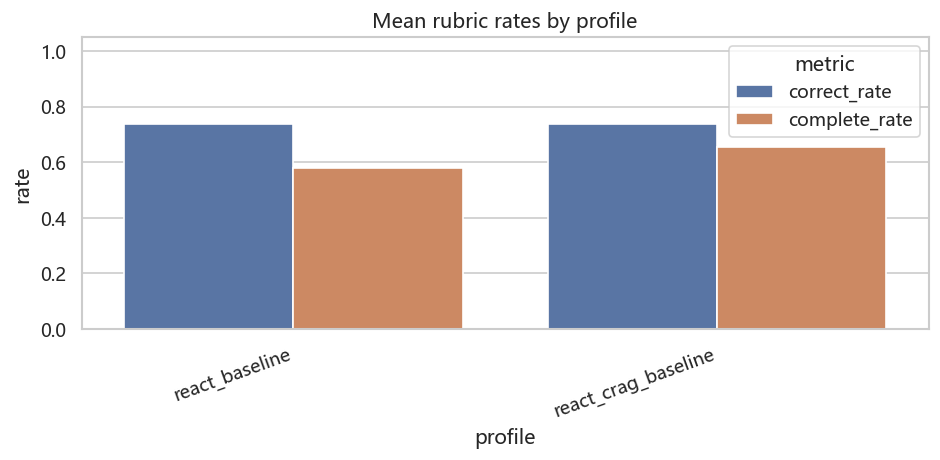

In [3]:
mean_rows = []
for profile, metrics in summary.items():
    mean_rows.append({"profile": profile, **metrics})
mean_df = pd.DataFrame(mean_rows).set_index("profile")
order = [p for p in PROFILE_ORDER if p in mean_df.index]
extra = [p for p in mean_df.index if p not in order]
mean_df = mean_df.loc[order + extra]

display(mean_df.round(3))

melted = mean_df.reset_index().melt(
    id_vars="profile",
    value_vars=["correct_rate", "complete_rate"],
    var_name="metric",
    value_name="rate",
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=melted, x="profile", y="rate", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Mean rubric rates by profile")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 2. Per-query heatmaps


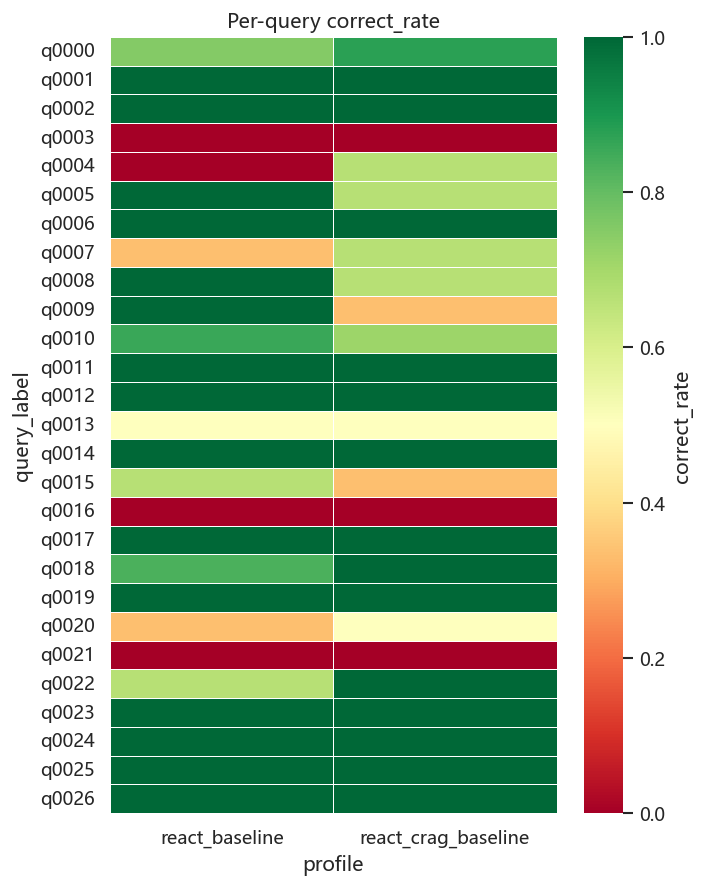

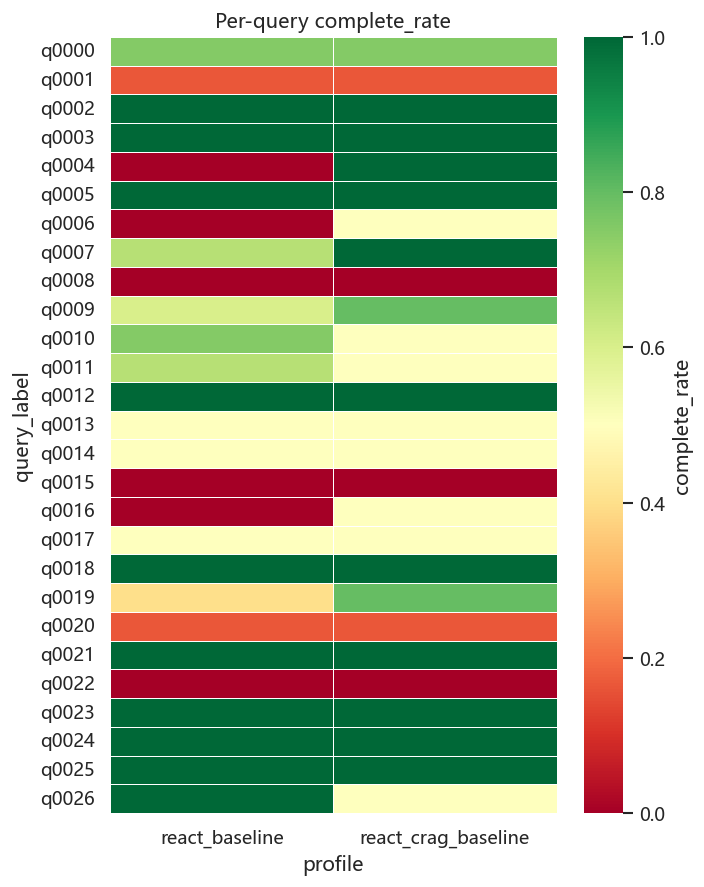

In [4]:
for metric in WINRATE_METRICS:
    pivot = joined_df.pivot(index="query_label", columns="profile", values=metric)
    pivot = pivot.sort_index(
        key=lambda labels: labels.str.replace("q", "", regex=False).astype(int)
    )
    col_order = [p for p in PROFILE_ORDER if p in pivot.columns]
    col_order += [p for p in pivot.columns if p not in col_order]
    pivot = pivot[col_order]

    fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(pivot.columns)), max(5, 0.28 * len(pivot))))
    sns.heatmap(
        pivot,
        vmin=0,
        vmax=1,
        cmap="RdYlGn",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": metric},
        ax=ax,
    )
    ax.set_title(f"Per-query {metric}")
    plt.tight_layout()
    plt.show()


## 3. Δ heatmap vs reference profile


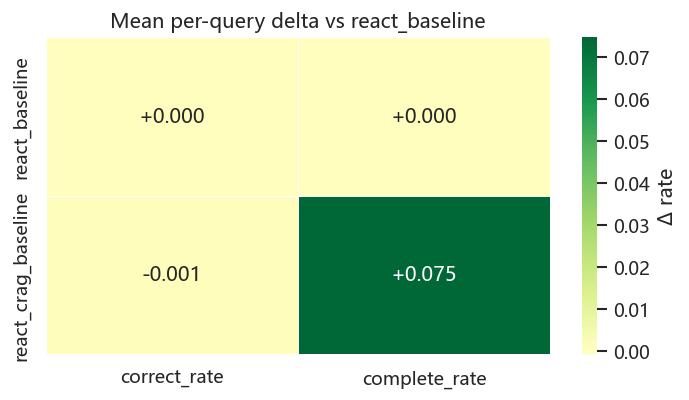

In [5]:
def delta_df(reference: str, metric_subset: list[str] | None = None) -> pd.DataFrame:
    metric_list = metric_subset or WINRATE_METRICS
    table = mean_delta_table(
        scores,
        reference_profile=reference,
        metrics=metric_list,  # type: ignore[arg-type]
    )
    table[reference] = {m: 0.0 for m in metric_list}
    df = pd.DataFrame(table).T
    order = [p for p in PROFILE_ORDER if p in df.index]
    rest = [p for p in df.index if p not in order]
    return df.loc[order + rest]


delta_ref = delta_df(REF_PROFILE)

fig, ax = plt.subplots(figsize=(6, max(3.5, 0.45 * len(delta_ref))))
sns.heatmap(
    delta_ref,
    annot=True,
    fmt="+.3f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Δ rate"},
)
ax.set_title(f"Mean per-query delta vs {REF_PROFILE}")
plt.tight_layout()
plt.show()


## 4. Winrate vs reference profile


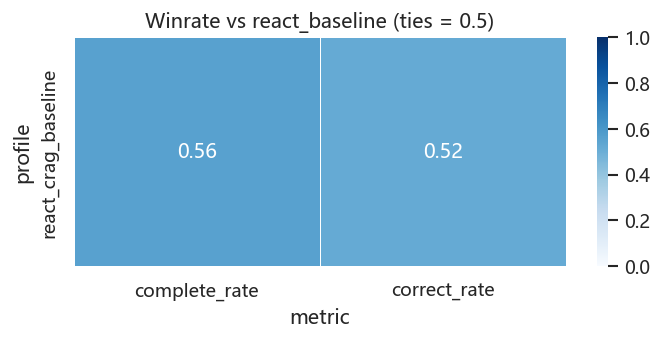

,profile,metric,winrate,wins,losses,ties
1,react_crag_baseline,complete_rate,0.556,6,3,18
0,react_crag_baseline,correct_rate,0.519,6,5,16


In [6]:
winrate_rows = []
for metric in WINRATE_METRICS:
    matrix = winrate_matrix(
        scores,
        reference_profile=REF_PROFILE,
        metric=metric,  # type: ignore[arg-type]
    )
    for pid, wr in matrix.items():
        winrate_rows.append(
            {
                "profile": pid,
                "metric": metric,
                "winrate": wr["winrate"],
                "wins": wr["wins"],
                "losses": wr["losses"],
                "ties": wr["ties"],
            }
        )

winrate_df = pd.DataFrame(winrate_rows)
if winrate_df.empty:
    print("No winrate data (need at least two profiles)")
else:
    pivot = winrate_df.pivot(index="profile", columns="metric", values="winrate")
    order = [p for p in PROFILE_ORDER if p in pivot.index and p != REF_PROFILE]
    pivot = pivot.loc[order]

    fig, ax = plt.subplots(figsize=(6, max(3, 0.4 * len(pivot))))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(f"Winrate vs {REF_PROFILE} (ties = 0.5)")
    plt.tight_layout()
    plt.show()
    display(winrate_df.sort_values(["metric", "winrate"], ascending=[True, False]).round(3))


## 5. Pattern ladder (absolute mean rates)


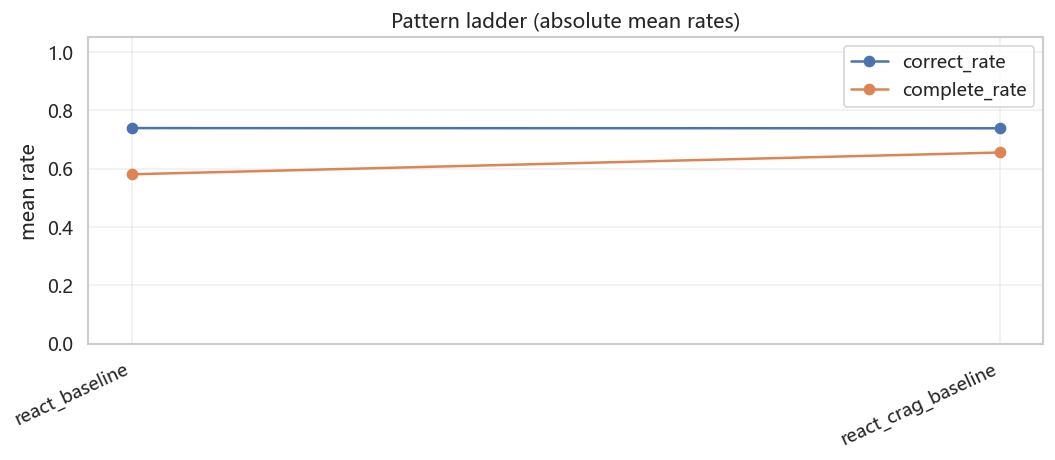

In [7]:
ladder_profiles = [p for p in PROFILE_ORDER if p in profiles]
ladder_metrics = WINRATE_METRICS

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ladder_profiles))
for metric in ladder_metrics:
    y = [summary[p][metric] for p in ladder_profiles]
    ax.plot(x, y, marker="o", label=metric)

ax.set_xticks(x)
ax.set_xticklabels(ladder_profiles, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean rate")
ax.set_title("Pattern ladder (absolute mean rates)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Per-query Δ distribution (selected pairs)


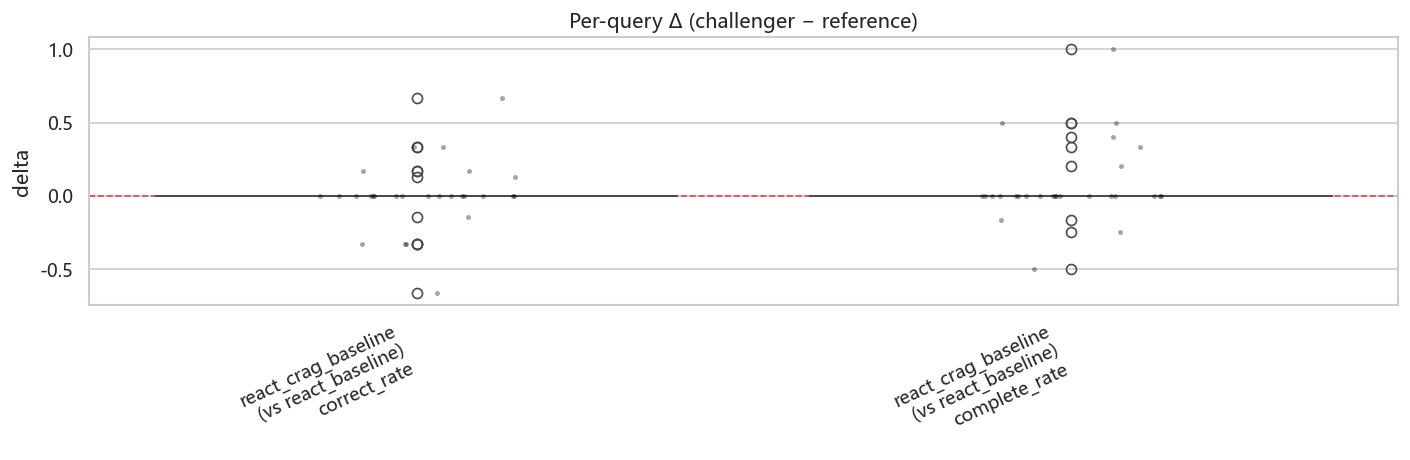

In [8]:
box_rows = []
for ref, challenger in DELTA_PAIRS:
    if ref not in profiles or challenger not in profiles:
        continue
    for metric in WINRATE_METRICS:
        deltas = per_query_delta(
            scores,
            reference_profile=ref,
            challenger_profile=challenger,
            metric=metric,  # type: ignore[arg-type]
        )
        label = f"{challenger}\n(vs {ref})\n{metric}"
        for qid, delta in deltas.items():
            box_rows.append({"pair": label, "delta": delta, "query_id": qid})

box_df = pd.DataFrame(box_rows)
if box_df.empty:
    print("No delta pairs to plot — edit DELTA_PAIRS or add more profiles")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.boxplot(data=box_df, x="pair", y="delta", ax=ax, color="steelblue")
    sns.stripplot(
        data=box_df,
        x="pair",
        y="delta",
        ax=ax,
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.15,
    )
    ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title("Per-query Δ (challenger − reference)")
    ax.set_xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


## 7. By question type


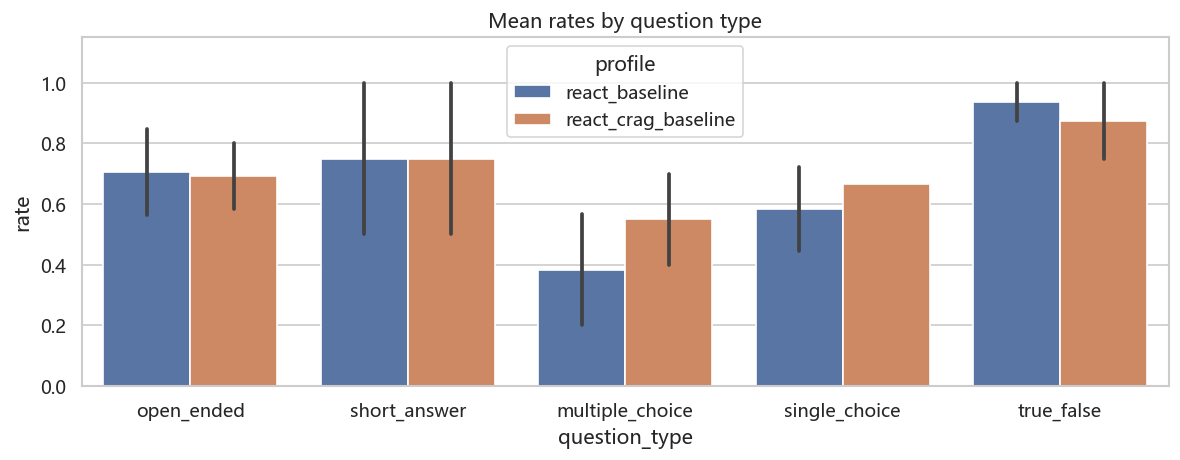

,question_type,profile,correct_rate,complete_rate
0,multiple_choice,react_baseline,0.567,0.200
1,multiple_choice,react_crag_baseline,0.700,0.400
2,open_ended,react_baseline,0.847,0.562
3,open_ended,react_crag_baseline,0.803,0.585
4,short_answer,react_baseline,0.500,1.000
5,short_answer,react_crag_baseline,0.500,1.000
6,single_choice,react_baseline,0.722,0.444
7,single_choice,react_crag_baseline,0.667,0.667
8,true_false,react_baseline,1.000,0.875
9,true_false,react_crag_baseline,1.000,0.750


In [9]:
type_df = (
    joined_df.groupby(["question_type", "profile"], as_index=False)[
        ["correct_rate", "complete_rate"]
    ]
    .mean()
)
type_melt = type_df.melt(
    id_vars=["question_type", "profile"],
    value_vars=["correct_rate", "complete_rate"],
    var_name="metric",
    value_name="rate",
)
type_order = [t for t in QUESTION_TYPE_ORDER if t in type_melt["question_type"].unique()]
type_melt["question_type"] = pd.Categorical(type_melt["question_type"], categories=type_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=type_melt, x="question_type", y="rate", hue="profile", ax=ax)
ax.set_ylim(0, 1.15)
ax.set_title("Mean rates by question type")
plt.tight_layout()
plt.show()

display(type_df.sort_values(["question_type", "profile"]).round(3))


## 8. Top rubric failures


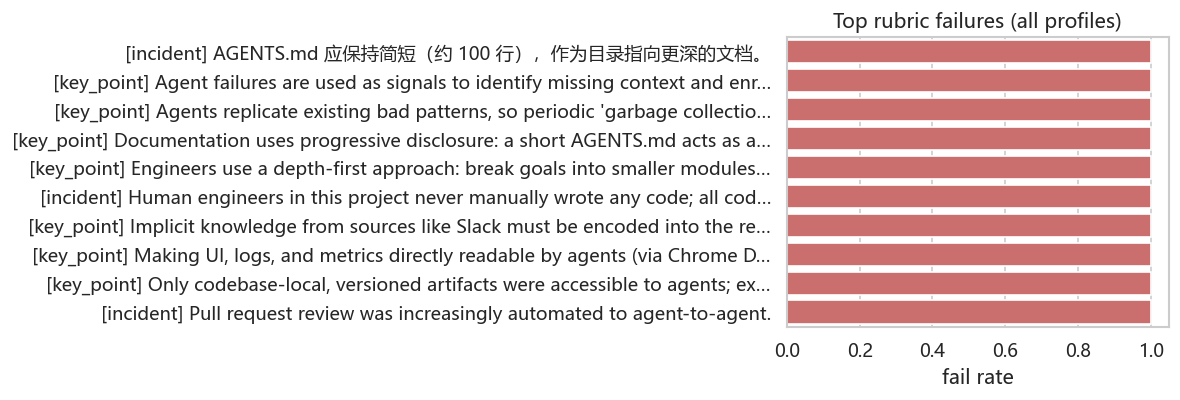

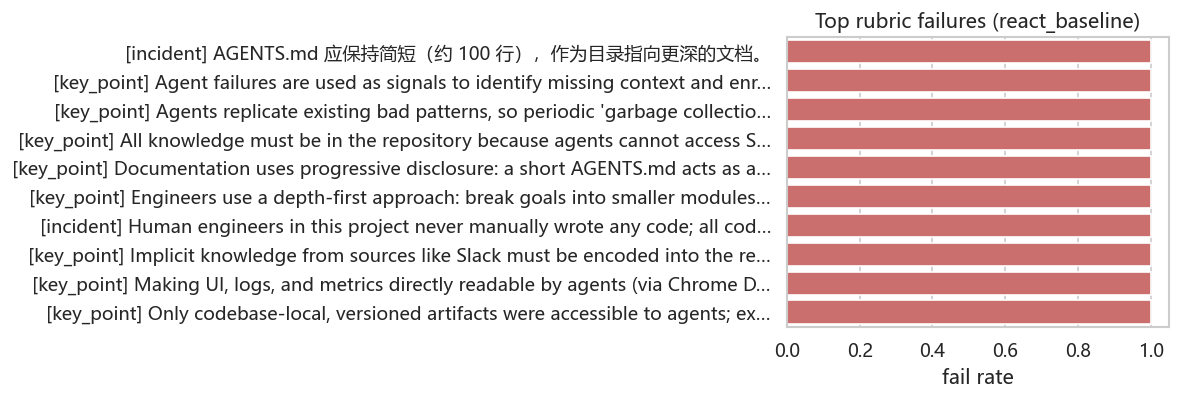

In [10]:
for profile in [None, REF_PROFILE]:
    failures = failure_counts(scores, profile=profile, top_n=10)
    title = "all profiles" if profile is None else profile
    if not failures:
        print(f"No failures for {title}")
        continue

    labels = [
        f"[{row.bucket}] {row.item[:70]}{'…' if len(row.item) > 70 else ''}"
        for row in failures
    ]
    rates = [row.fail_rate for row in failures]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.35 * len(failures))))
    sns.barplot(x=rates, y=labels, orient="y", color="#d95f5f", ax=ax)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("fail rate")
    ax.set_title(f"Top rubric failures ({title})")
    plt.tight_layout()
    plt.show()


## 9. Diagnostic: correct vs complete


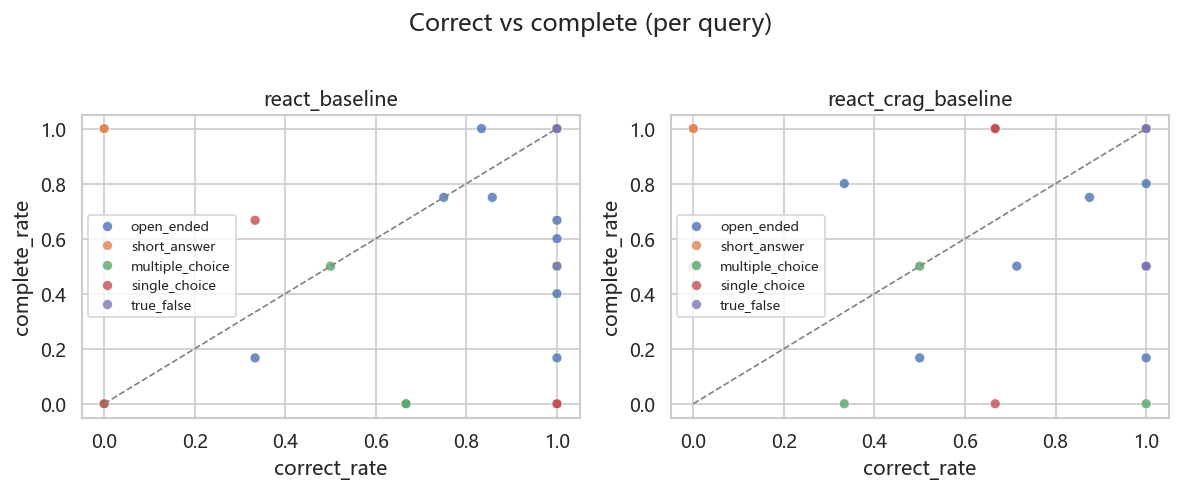

,profile,query_label,question_type,correct_rate,complete_rate,question
6,react_baseline,q0006,single_choice,1.0,0.000000,为了保持完全由智能体生成的代码库的架构连贯性，团队采取了哪种核心策略？
8,react_baseline,q0008,single_choice,1.0,0.000000,根据文章，在完全由 Codex 智能体生成代码的项目中，人类工程师的核心角色转变为什么？
1,react_baseline,q0001,open_ended,1.0,0.166667,"文章中指出，为智能体提供情境时应该“给 Codex 一张地图，而不是一本 1,000 页的说..."
19,react_baseline,q0019,open_ended,1.0,0.400000,"文章提出智能体情境管理应遵循“给 Codex 一张地图，而不是一本 1,000 页的说明书”..."
49,react_crag_baseline,q0022,multiple_choice,1.0,0.000000,根据文章，团队在完全由 Codex 智能体生成代码的项目中采用了哪些关键策略来提高效率与可维护性？
28,react_crag_baseline,q0001,open_ended,1.0,0.166667,"文章中指出，为智能体提供情境时应该“给 Codex 一张地图，而不是一本 1,000 页的说..."


In [11]:
fig, axes = plt.subplots(1, len(profiles), figsize=(5 * len(profiles), 4), squeeze=False)
for ax, profile in zip(axes[0], profiles):
    sub = joined_df[joined_df["profile"] == profile]
    sns.scatterplot(
        data=sub,
        x="correct_rate",
        y="complete_rate",
        hue="question_type",
        ax=ax,
        alpha=0.8,
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(profile)
    ax.legend(loc="best", fontsize=8)

plt.suptitle("Correct vs complete (per query)", y=1.02)
plt.tight_layout()
plt.show()

lag = joined_df[(joined_df["correct_rate"] >= 0.8) & (joined_df["complete_rate"] < 0.5)]
if lag.empty:
    print("No high-correct / low-complete outliers")
else:
    display(
        lag[["profile", "query_label", "question_type", "correct_rate", "complete_rate", "question"]]
        .sort_values(["profile", "complete_rate"])
        .head(12)
    )


## 10. Quick interpretation checklist

- **correct_rate low, complete_rate ok** → retrieval may be fine; answer misses core factual claims.
- **complete_rate << correct_rate** → answer hits main facts but skips nuance / structure / trade-offs.
- **open_ended lagging short_answer** → long-form synthesis or multi-hop reasoning is the bottleneck.
- **Δ winrate < 0.5 for CRAG/Self-RAG** → reflection loop may add cost without better rubric scores.
- **same rubric item fails across profiles** → gold checklist item may be too strict, or source chunk not retrieved.
- **same item fails on one profile only** → compare retrieval traces for those queries (`analysis/replay/`).
